[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Dragomier/Machine_Learning_2026/blob/main/Homework8.ipynb)

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Fix the random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Define ellipse parameters
focus1 = torch.tensor([-2.0, 0.0])  # First focus
focus2 = torch.tensor([2.0, 0.0])   # Second focus
constant_sum = 6.0  # The sum of distances to the two foci

# Initialize random 2D points from uniform distribution
num_points = 100
points = torch.rand((num_points, 2)) * 10 - 5  # Uniformly distributed in [-5, 5]
points.requires_grad = True

# Reset trajectories
trajectories = [[] for _ in range(num_points)]
loss_history = []


In [4]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
%matplotlib inline

def train_points(loss_fun, num_epochs, learning_rate):
    optimizer = torch.optim.Adam([points], lr=learning_rate)
    trajectories = []

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        loss = loss_fun(points, focus1, focus2)
        loss.backward()
        optimizer.step()

        trajectories.append(points.detach().cpu().clone())

    return trajectories

def make_animation_for_loss(loss, num_epochs, learning_rate):
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    scatter1 = ax.scatter(points[:, 0].detach().cpu().numpy(), points[:, 1].detach().cpu().numpy(), label=f'Points - Epoch {0}')

    f1 = focus1.detach().cpu().numpy()
    f2 = focus2.detach().cpu().numpy()
    scatter2 = ax.scatter([f1[0], f2[0]], [f1[1], f1[1]], color='red', marker='x', s=100, label='Foci')

    lines = [
      ax.plot([], [], color='gray', linewidth=0.5)[0]
      for _ in range(num_points)
    ]
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.legend()

    data_points = train_points(loss, num_epochs, learning_rate)

    def update(frame):
        # Get the current set of points for the scatter plot
        current_epoch_index = 10 * frame
        if current_epoch_index < len(data_points):
            scatter1.set_offsets(data_points[current_epoch_index].detach().cpu().numpy())
        else:
            # If frame goes beyond available data, show the last known state
            scatter1.set_offsets(data_points[-1].detach().cpu().numpy())

        # Update trajectories for each point
        for i, line in enumerate(lines):
            # Collect the i-th point from each epoch up to the current frame
            # data_points is a list of tensors, where each tensor is (num_points, 2)
            point_trajectory_tensors = [data_points[k][i] for k in range(min(current_epoch_index + 1, len(data_points)))]

            if point_trajectory_tensors: # Ensure the list is not empty before stacking
                traj = torch.stack(point_trajectory_tensors).detach().cpu().numpy()
                line.set_data(traj[:, 0], traj[:, 1])
            else:
                line.set_data([], []) # Clear line if no data yet
        return (scatter1,) + tuple(lines)

    anim = FuncAnimation(fig, update, frames=num_epochs//10, interval=100)
    display(HTML(anim.to_jshtml()))

In [ ]:
loss_0 = lambda points, focus1, focus2: torch.mean(
    torch.mean(torch.where(torch.norm(points - focus1, dim=1) +
              torch.norm(points - focus2, dim=1) - constant_sum == 0, 0, 1))
)
#make_animation_for_loss(loss_0, num_epochs, learning_rate)


UnboundLocalError: cannot access local variable 'points' where it is not associated with a value

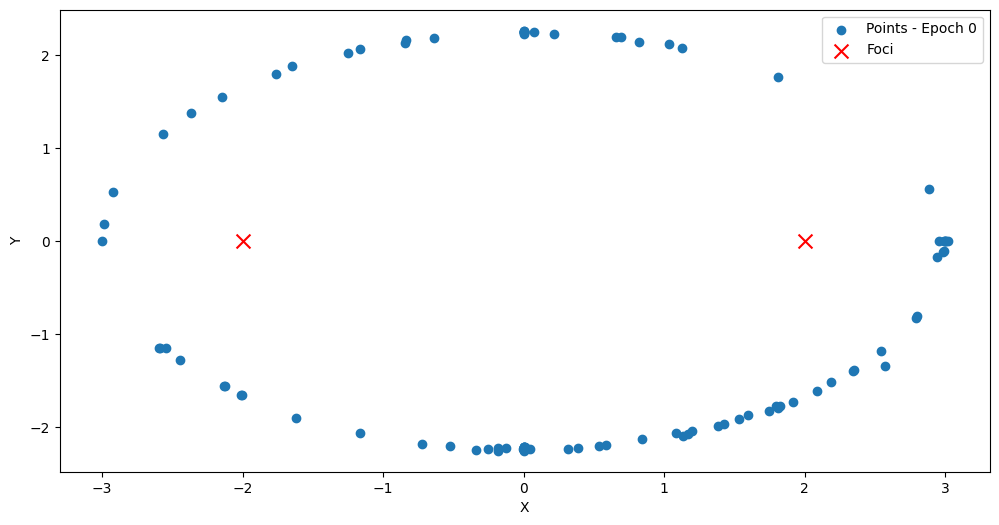

In [5]:
num_epochs = 1000
learning_rate = 0.1

loss_1 = lambda points, focus1, focus2: torch.mean(
    torch.abs(torch.norm(points - focus1, dim=1) +
              torch.norm(points - focus2, dim=1) - constant_sum)
)
make_animation_for_loss(loss_1, num_epochs, learning_rate)



In [ ]:
loss_inf = lambda points, focus1, focus2: torch.max(
    torch.abs(torch.norm(points - focus1, dim=1) +
              torch.norm(points - focus2, dim=1) - constant_sum)
)
make_animation_for_loss(loss_inf, num_epochs, learning_rate)

# Conclusion